In [1]:
library(stats)
library(tidyverse)
library(ggplot2)
library(patchwork)
library(car)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::%||%()   masks base::%||%()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




# Check if model is correctly specified


## Omitted variables


In [2]:
set.seed(1)
n <- 100
x1 <- rnorm(n, mean = 5, sd = 2)
x2 <- rpois(n, lambda = 10)
x3 <- rpois(n, lambda = 1)
y <- 3 + (2 * x1) + (1.5 * x2) + (3 * x3) + rnorm(n, mean = 0, sd = 2) # The observed data is a function of the 2 variables x1 and x2

df <- data.frame(x1 = x1, x2 = x2, x3 = x3, y = y)
head(df)


,x1,x2,x3,y
,<dbl>,<int>,<int>,<dbl>
1,3.747092,8,0,18.71413
2,5.367287,10,1,30.55495
3,3.328743,7,1,19.72848
4,8.190562,6,0,27.53913
5,5.659016,15,2,43.43831
6,3.359063,12,2,37.12327


In [3]:
model1 <- lm(formula = y ~ x1, data = df)
summary(model1)



Call:
lm(formula = y ~ x1, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.5466  -4.5349  -0.5704   3.7807  17.8914 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   19.581      1.892  10.351  < 2e-16 ***
x1             2.208      0.343   6.439 4.48e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.13 on 98 degrees of freedom
Multiple R-squared:  0.2973,	Adjusted R-squared:  0.2901 
F-statistic: 41.46 on 1 and 98 DF,  p-value: 4.48e-09


In [4]:
model2 <- lm(formula = y ~ x1 + x2, data = df)
summary(model2)



Call:
lm(formula = y ~ x1 + x2, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.9908 -2.8250 -0.2765  2.7339  9.2147 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.1121     1.5821   3.863 0.000202 ***
x1            2.0313     0.2124   9.563 1.18e-15 ***
x2            1.4977     0.1185  12.634  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.788 on 97 degrees of freedom
Multiple R-squared:  0.7344,	Adjusted R-squared:  0.7289 
F-statistic: 134.1 on 2 and 97 DF,  p-value: < 2.2e-16


In [5]:
model3 <- lm(formula = y ~ x1 + x2 + x3, data = df)
summary(model3)



Call:
lm(formula = y ~ x1 + x2 + x3, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.6445 -1.1799  0.1120  0.9866  3.8813 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.26538    0.74976   3.021  0.00322 ** 
x1           2.20695    0.09743  22.651  < 2e-16 ***
x2           1.42928    0.05425  26.345  < 2e-16 ***
x3           3.32180    0.17291  19.211  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.73 on 96 degrees of freedom
Multiple R-squared:  0.9452,	Adjusted R-squared:  0.9435 
F-statistic: 551.6 on 3 and 96 DF,  p-value: < 2.2e-16


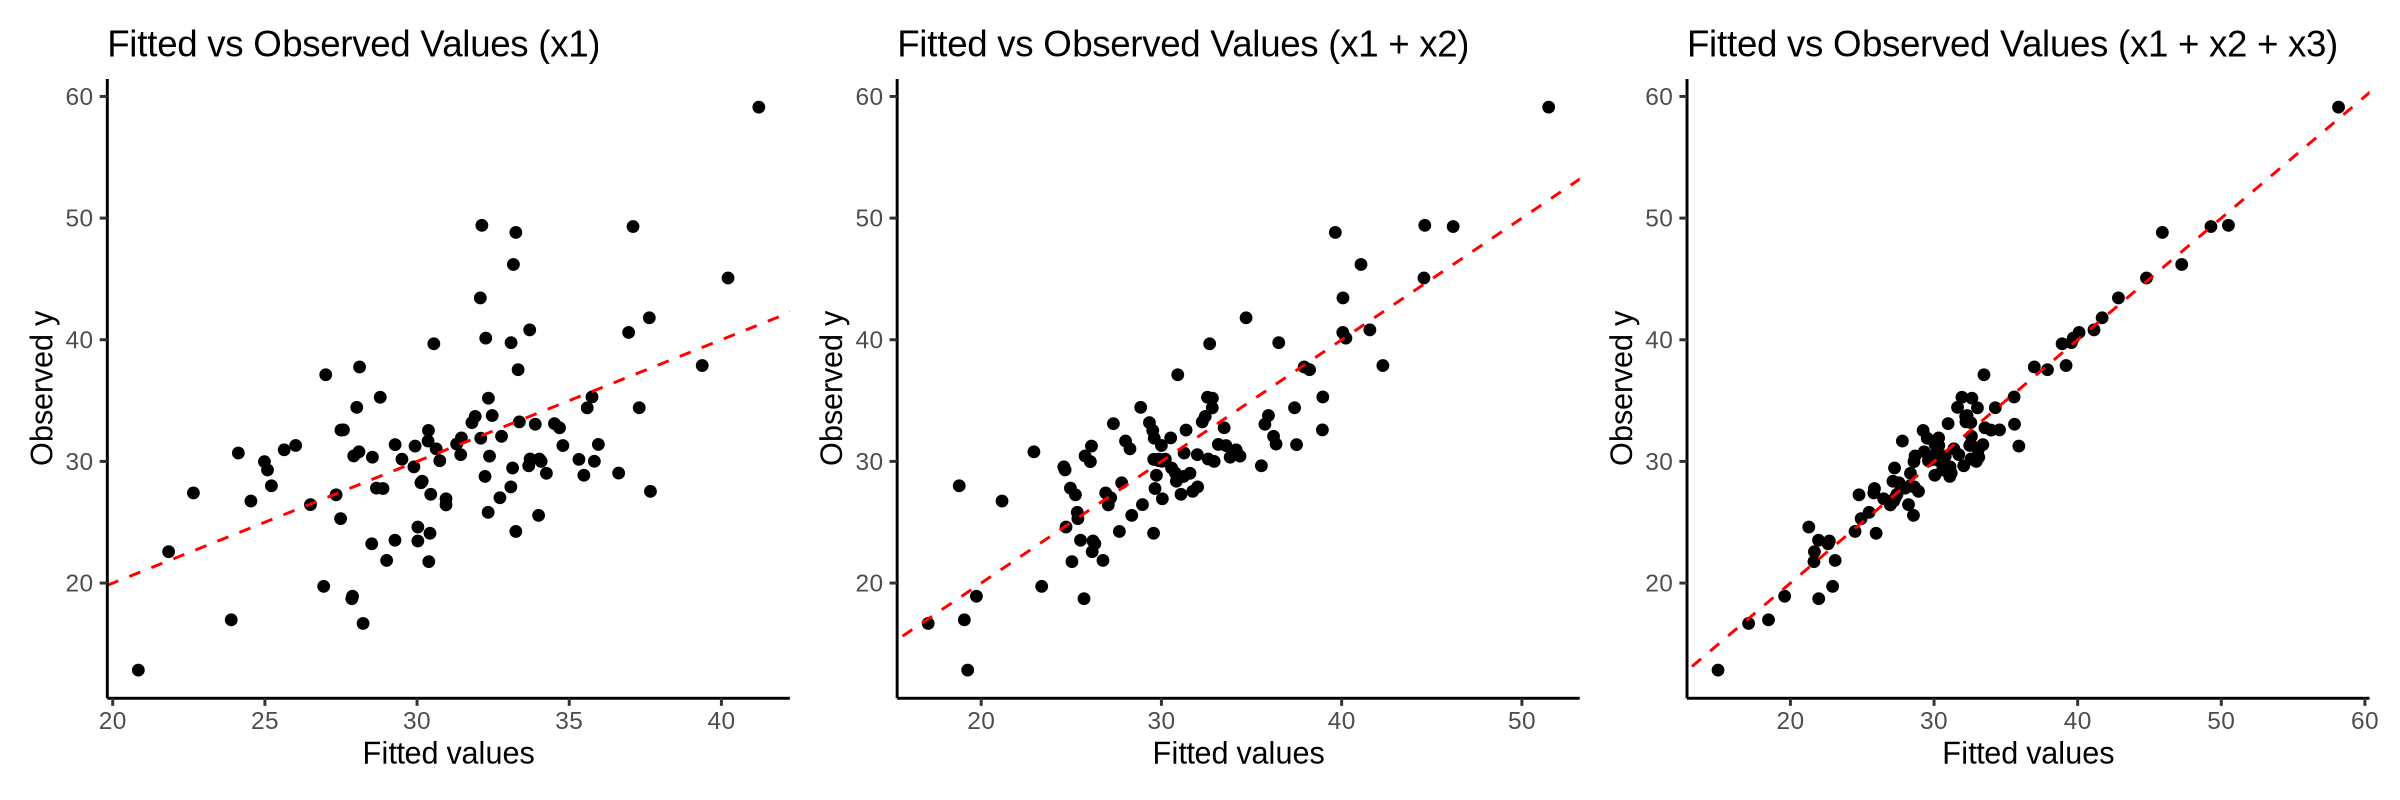

In [7]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

df$fitted <- fitted(model1)
plt1 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1)") +
    theme_classic()

df$fitted <- fitted(model2)
plt2 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1 + x2)") +
    theme_classic()

df$fitted <- fitted(model3)
plt3 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1 + x2 + x3)") +
    theme_classic()

plt1 + plt2 + plt3


- If the fitted values correlate well with the observed values, the model is more likely to not omit important variables


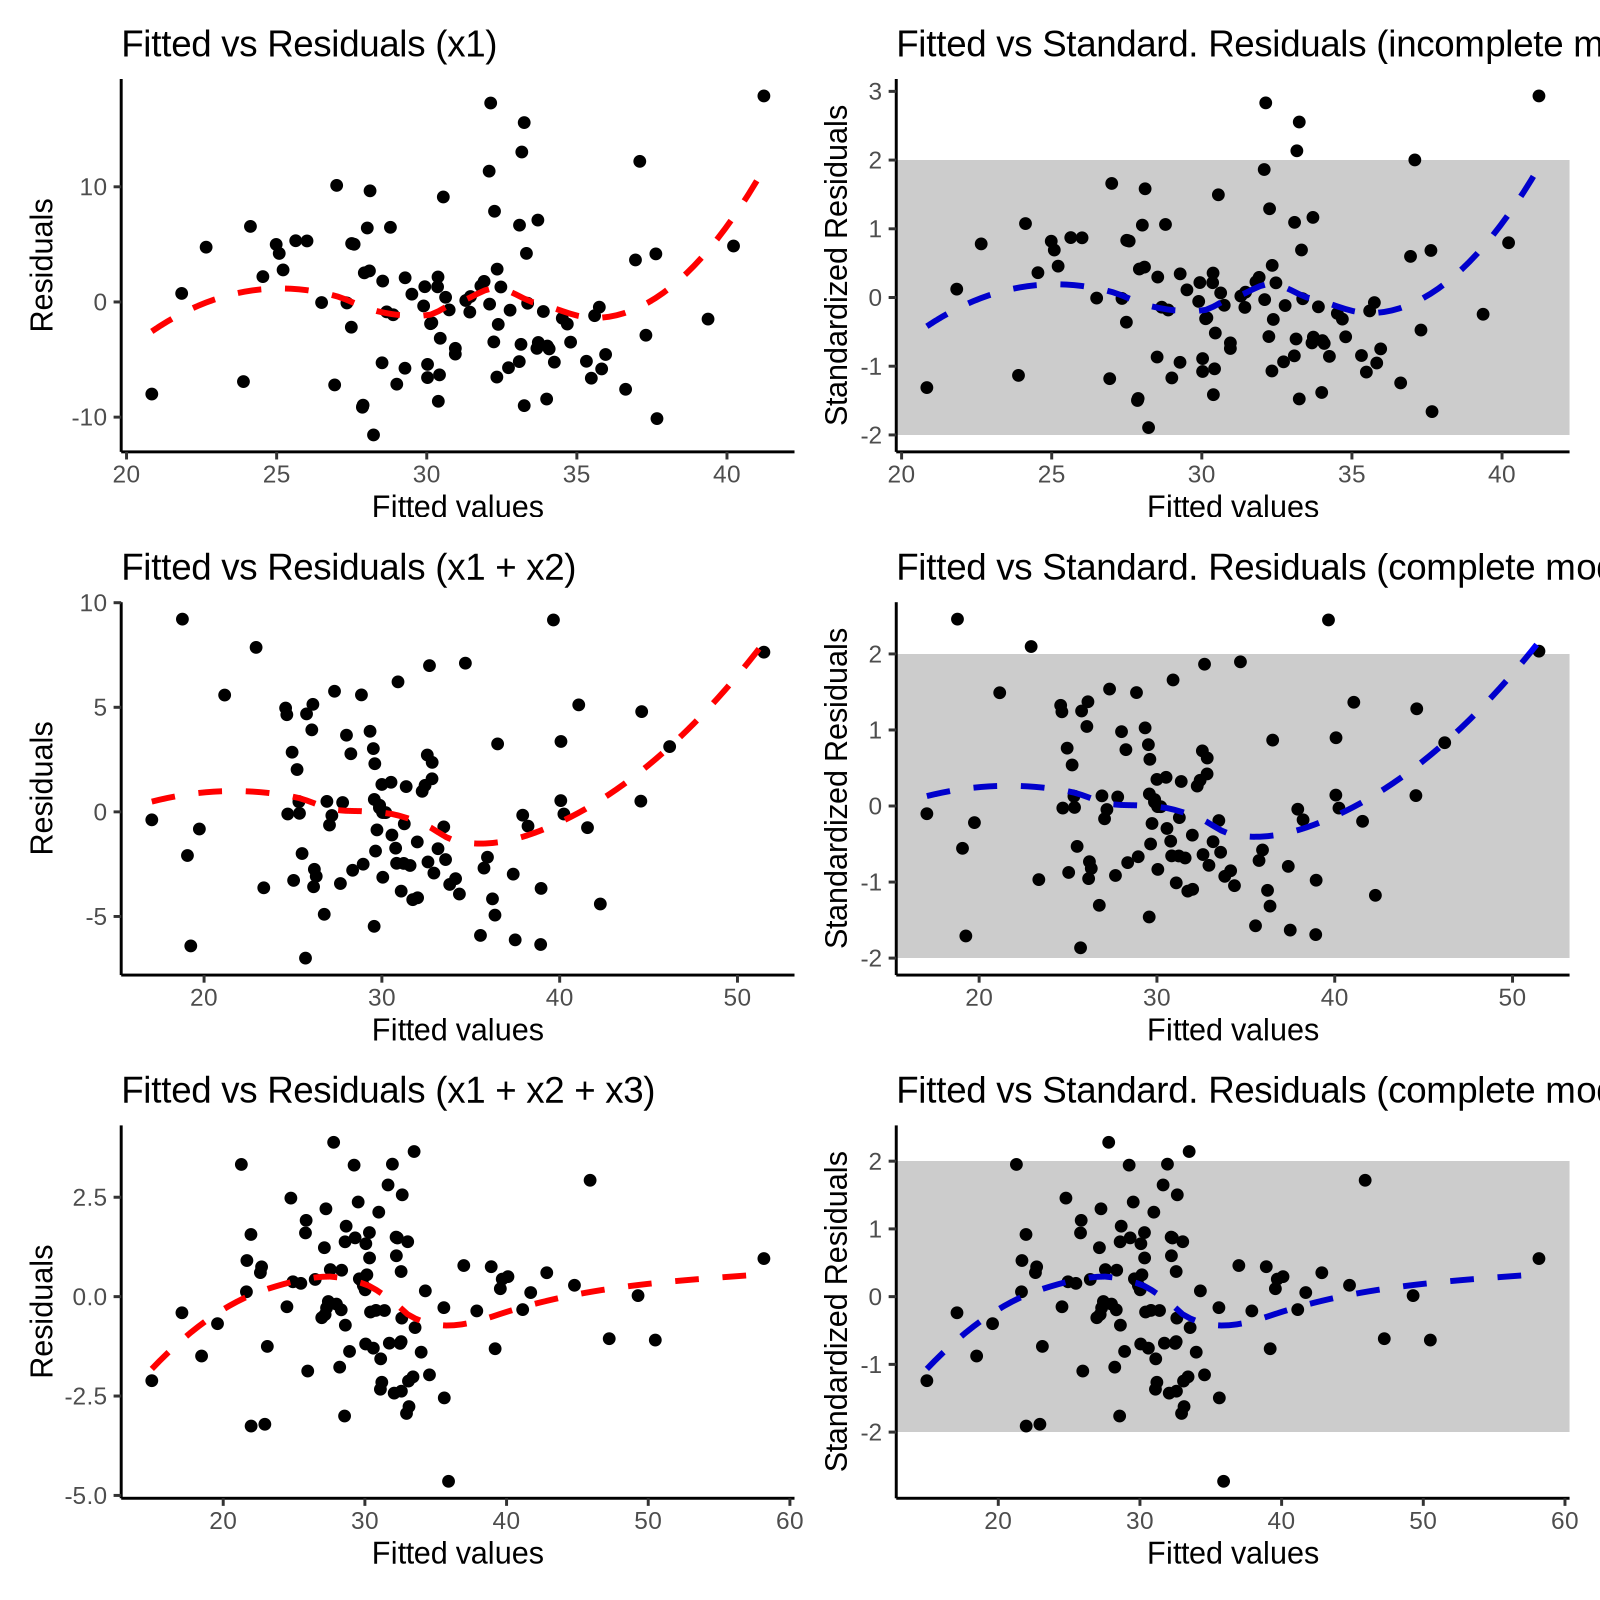

In [8]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

df$fitted <- fitted(model1)
df$residuals <- residuals(model1)
df$residuals_standardized <- residuals(model1) / sd(residuals(model1))

plt1 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1)") +
    theme_classic()

plt2 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (incomplete model)") +
    theme_classic()

df$fitted <- fitted(model2)
df$residuals <- residuals(model2)
df$residuals_standardized <- residuals(model2) / sd(residuals(model2))

plt3 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1 + x2)") +
    theme_classic()

plt4 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()


df$fitted <- fitted(model3)
df$residuals <- residuals(model3)
df$residuals_standardized <- residuals(model3) / sd(residuals(model3))

plt5 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1 + x2 + x3)") +
    theme_classic()

plt6 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()

(plt1 + plt2) / (plt3 + plt4) / (plt5 + plt6)


- The residuals are much smaller overall in the complete model, and the lowess follows closer to 0
- but without knowing the real data it would be difficult to say if the incomplete model explains most of the effect just by those plots


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.02”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 1.02”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 1”


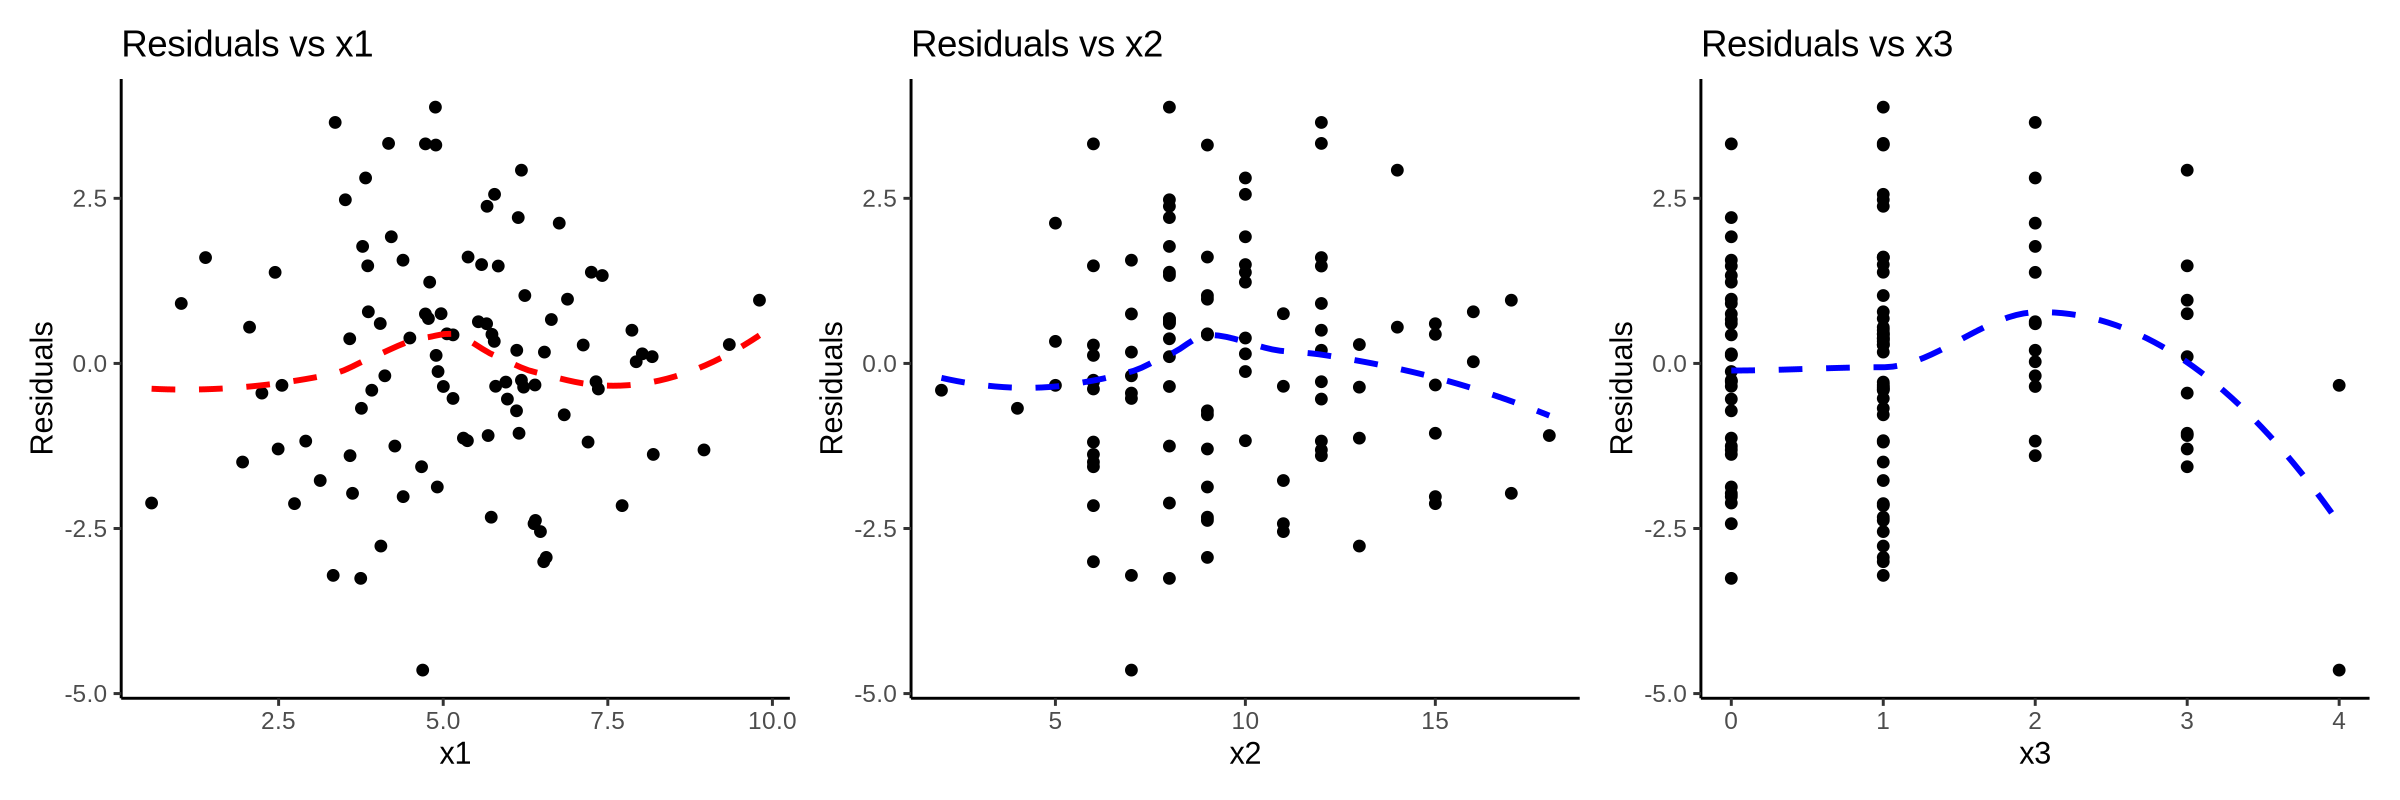

In [10]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

plt_x1 <- ggplot(df, aes(x = x1, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "x1", y = "Residuals", title = "Residuals vs x1") +
    theme_classic()

plt_x2 <- ggplot(df, aes(x = x2, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    labs(x = "x2", y = "Residuals", title = "Residuals vs x2") +
    theme_classic()

plt_x3 <- ggplot(df, aes(x = x3, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    labs(x = "x3", y = "Residuals", title = "Residuals vs x3") +
    theme_classic()

plt_x1 + plt_x2 + plt_x3


## Transformations


In [55]:
set.seed(1)
n <- 100
x1 <- rnorm(n, mean = 8, sd = 2)
x2 <- rnorm(n, mean = 10, sd = 3)
x3 <- rnorm(n, mean = 30, sd = 3)
# x3 <- rpois(n, lambda = 1)
y <- 3 + (2 * x1) * (1.5 * x2) * (3 * x3) * exp(rnorm(n, mean = 0, sd = 2)) # The observed data is a non-linear function of the 2 variables x1 and x2

df <- data.frame(x1 = x1, x2 = x2, x3 = x3, y = y)
head(df)
dim(df)


,x1,x2,x3,y
,<dbl>,<dbl>,<dbl>,<dbl>
1,6.747092,8.138900,31.22821,92197.926
2,8.367287,10.126348,35.06662,3295.322
3,6.328743,7.267235,34.75977,741804.820
4,11.190562,10.474086,29.00728,14209.886
5,8.659016,8.036246,23.14429,396263.274
6,6.359063,15.301862,37.49298,675807.689


[1] 100   4

In [38]:
model1 <- lm(formula = y ~ x1 + x2 + x3, data = df)
summary(model1)



Call:
lm(formula = y ~ x1 + x2 + x3, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-182178 -104259  -46701    -172  763757 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)  -325246     207707  -1.566   0.1207  
x1             -2309      10151  -0.227   0.8206  
x2              8439       6353   1.328   0.1872  
x3             12042       5884   2.046   0.0434 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 181400 on 96 degrees of freedom
Multiple R-squared:  0.05636,	Adjusted R-squared:  0.02687 
F-statistic: 1.911 on 3 and 96 DF,  p-value: 0.1329


In [39]:
model2 <- lm(formula = y ~ x1 + x2 + x3, data = df)
summary(model2)



Call:
lm(formula = y ~ x1 + x2 + x3, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-182178 -104259  -46701    -172  763757 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)  -325246     207707  -1.566   0.1207  
x1             -2309      10151  -0.227   0.8206  
x2              8439       6353   1.328   0.1872  
x3             12042       5884   2.046   0.0434 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 181400 on 96 degrees of freedom
Multiple R-squared:  0.05636,	Adjusted R-squared:  0.02687 
F-statistic: 1.911 on 3 and 96 DF,  p-value: 0.1329


In [56]:
model3 <- lm(log(y) ~ log(x1) + log(x2) + log(x3), data = df)
summary(model3)



Call:
lm(formula = log(y) ~ log(x1) + log(x2) + log(x3), data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.2995 -1.0913 -0.0068  1.2468  3.6394 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  -2.9842     6.8837  -0.434    0.666
log(x1)       0.8619     0.8485   1.016    0.312
log(x2)       0.4202     0.6735   0.624    0.534
log(x3)       3.0233     1.8936   1.597    0.114

Residual standard error: 1.991 on 96 degrees of freedom
Multiple R-squared:  0.03982,	Adjusted R-squared:  0.009815 
F-statistic: 1.327 on 3 and 96 DF,  p-value: 0.2701


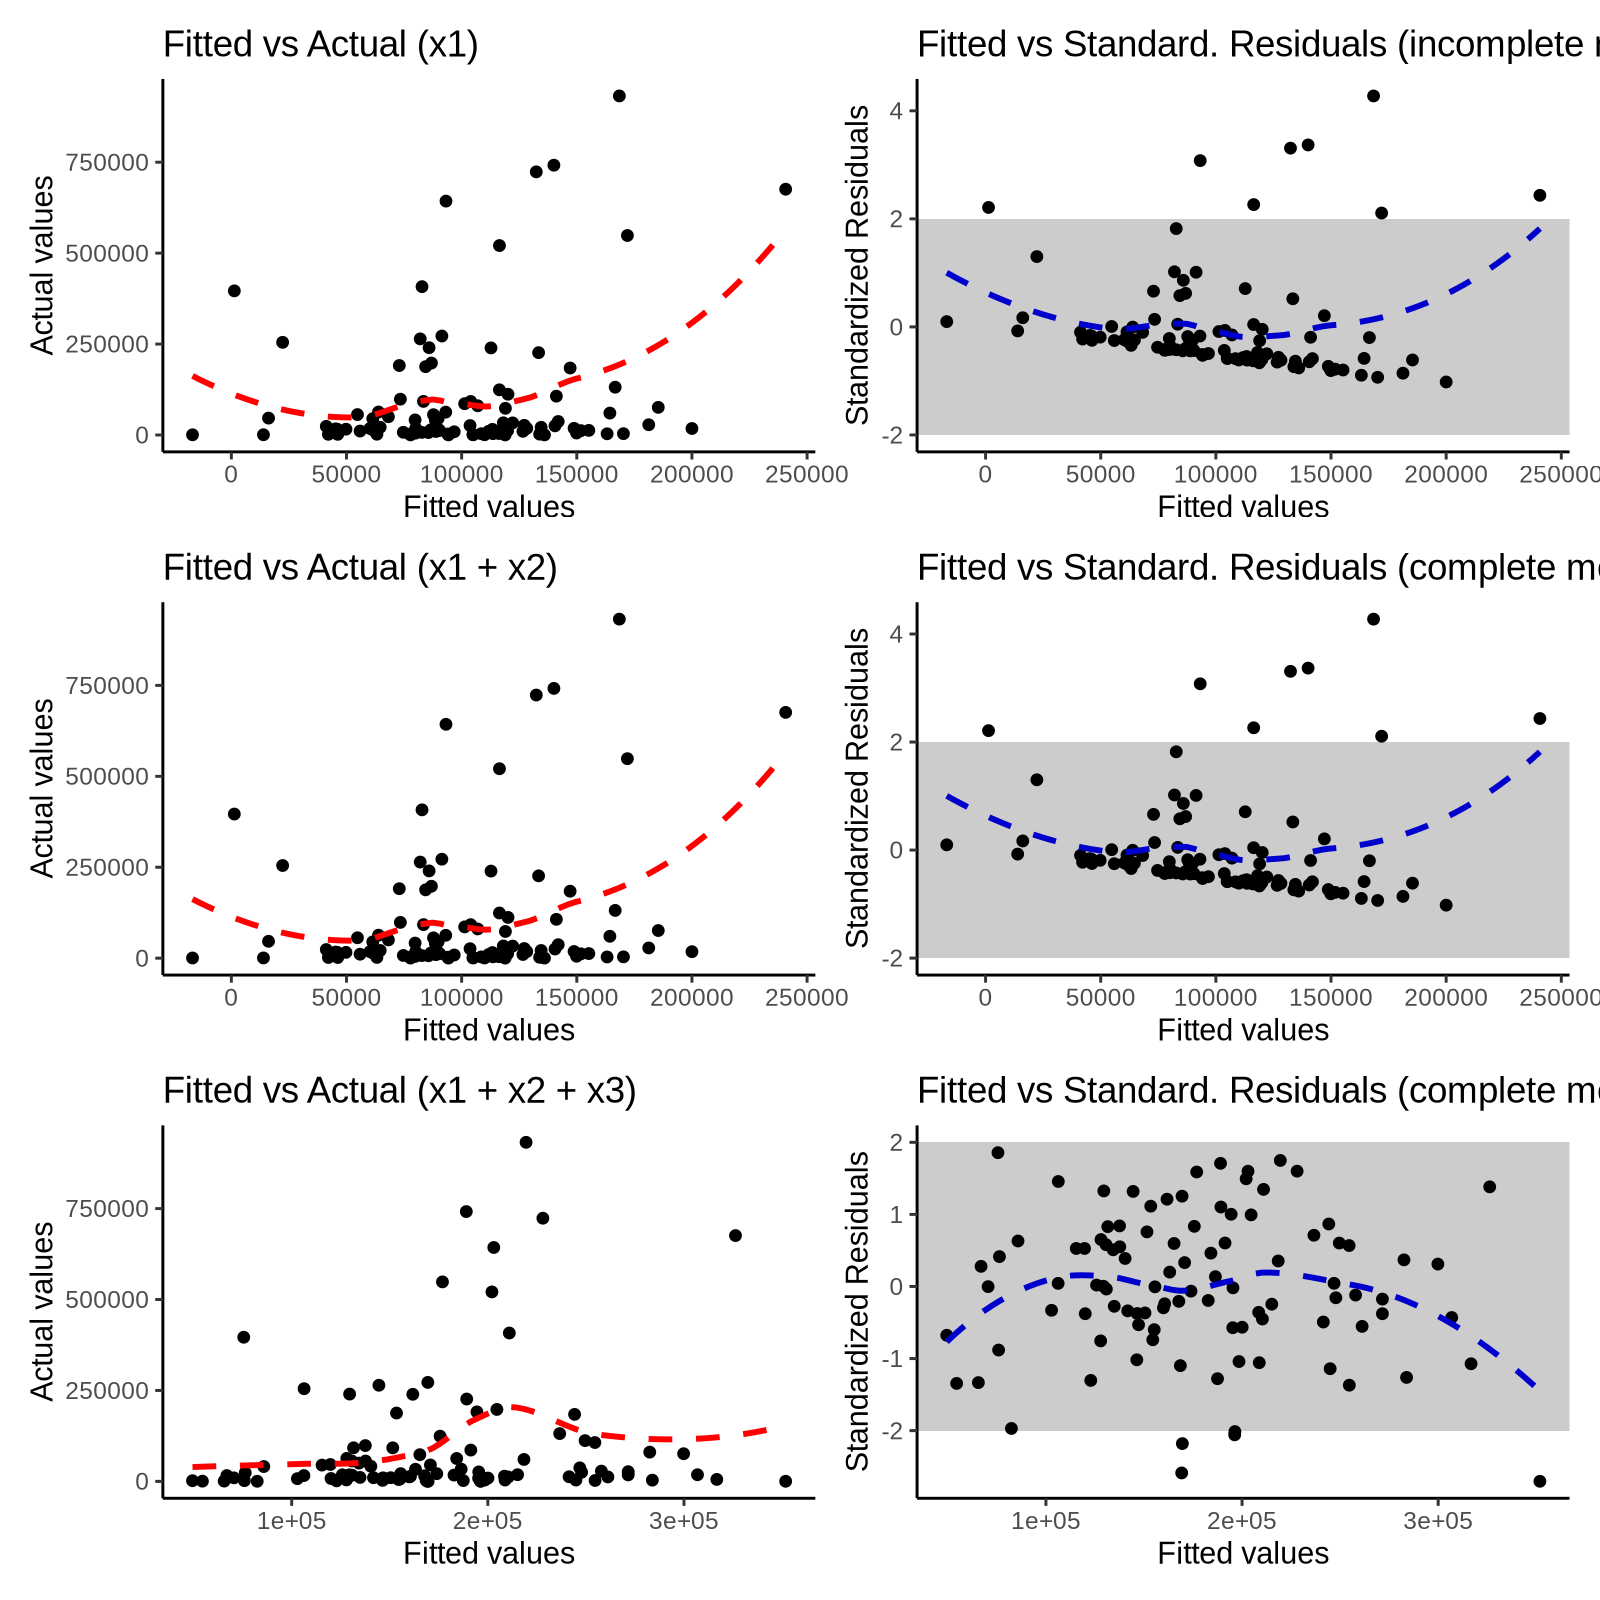

In [57]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

df$fitted <- fitted(model1)
df$residuals <- residuals(model1)
df$residuals_standardized <- residuals(model1) / sd(residuals(model1))

plt1 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Actual values", title = "Fitted vs Actual (x1)") +
    theme_classic()

plt2 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (incomplete model)") +
    theme_classic()

df$fitted <- fitted(model2)
df$residuals <- residuals(model2)
df$residuals_standardized <- residuals(model2) / sd(residuals(model2))

plt3 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Actual values", title = "Fitted vs Actual (x1 + x2)") +
    theme_classic()

plt4 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()


sigma2 <- summary(model3)$sigma^2
bias_correction <- exp(sigma2 / 2)
df$fitted <- exp(fitted(model3)) * bias_correction # this should have fixed the multiplicative error bias, but it is not enough
df$residuals <- residuals(model3)
df$residuals_standardized <- residuals(model3) / sd(residuals(model3))

plt5 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Actual values", title = "Fitted vs Actual (x1 + x2 + x3)") +
    theme_classic()

plt6 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()

(plt1 + plt2) / (plt3 + plt4) / (plt5 + plt6)


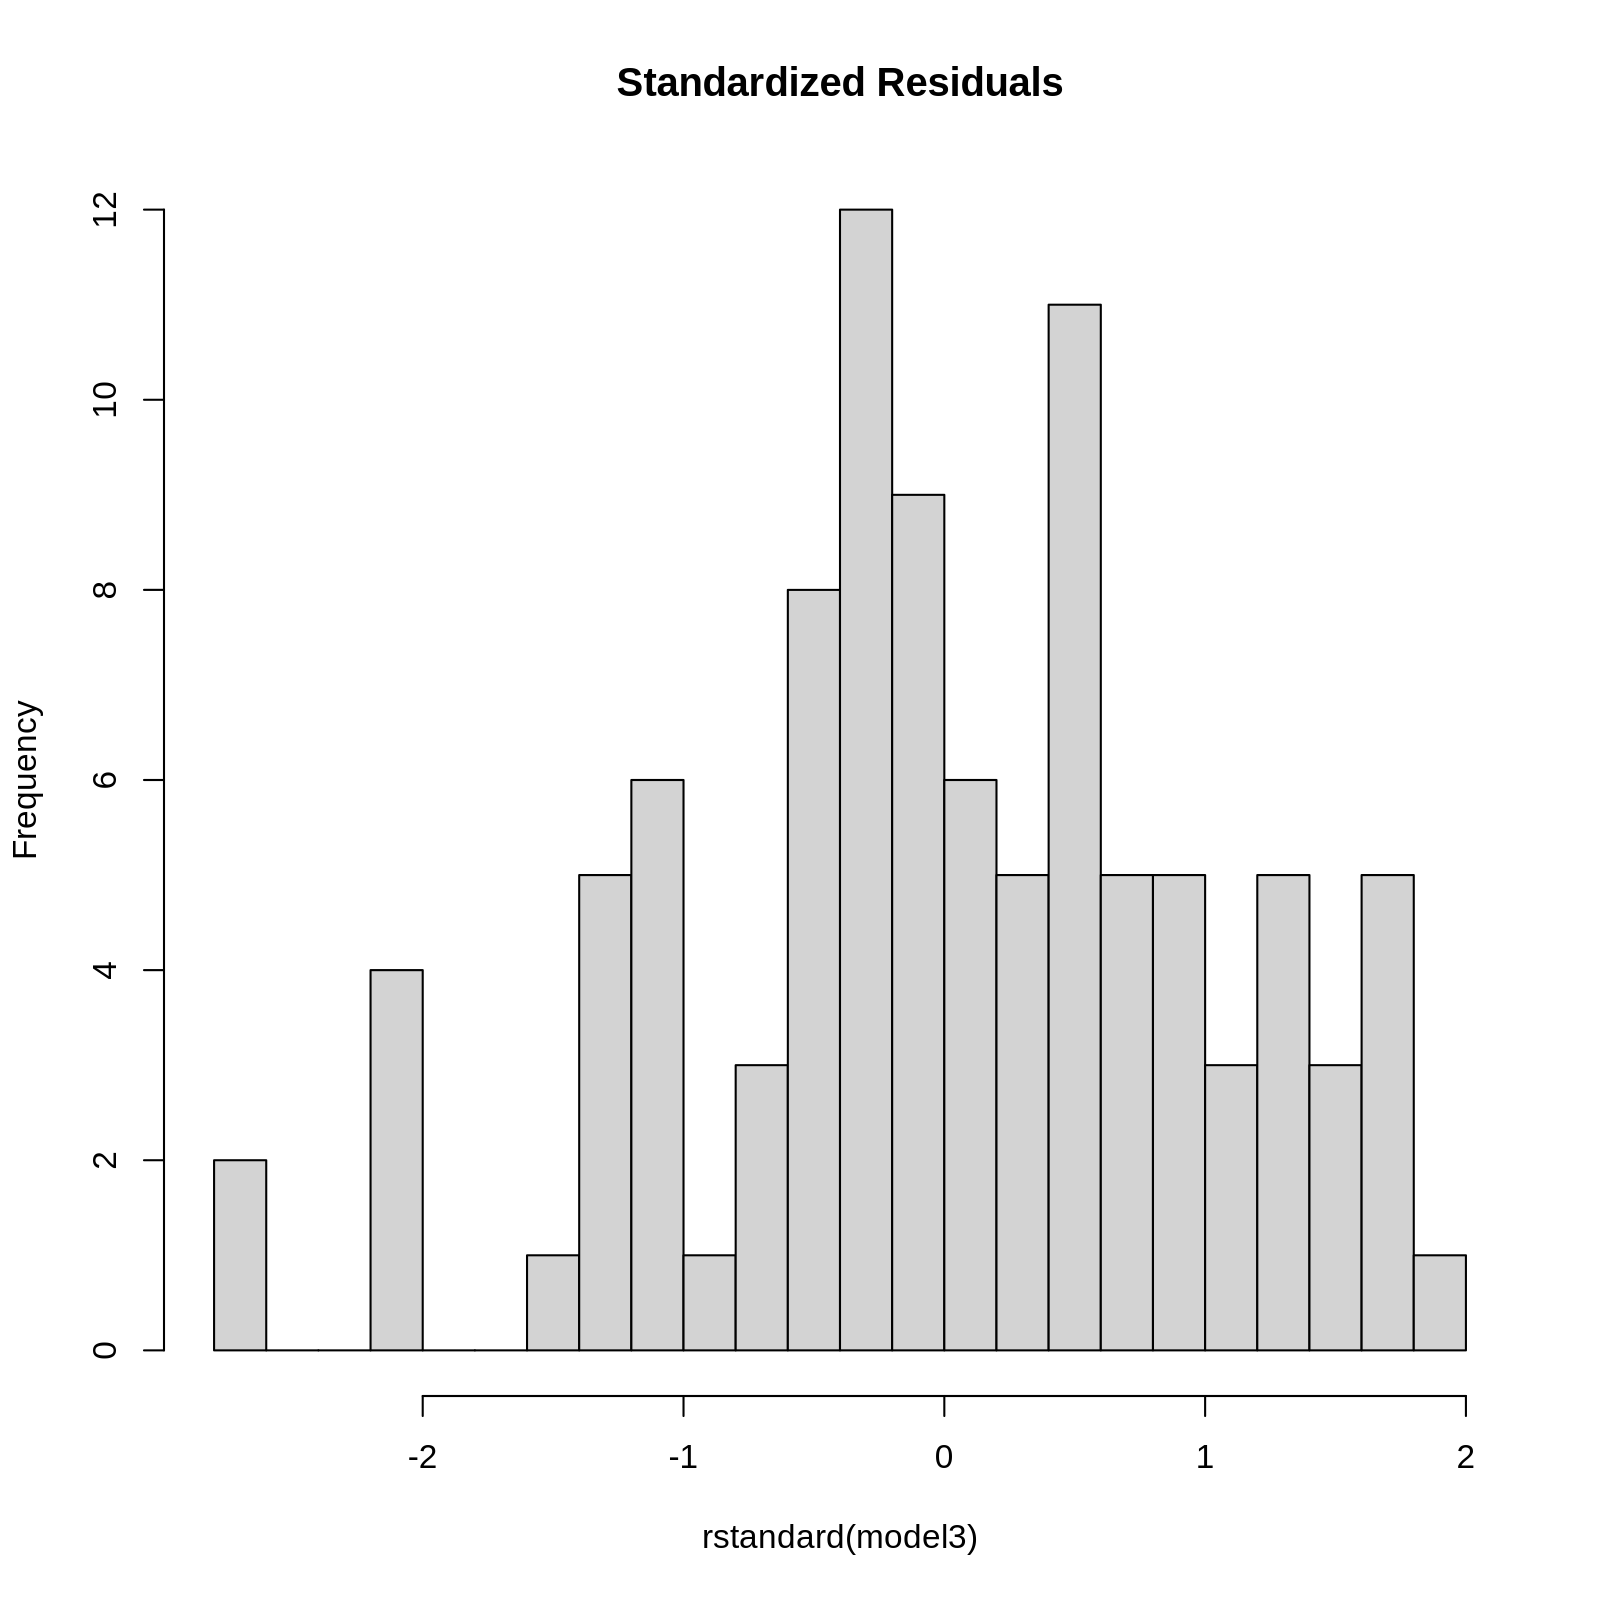

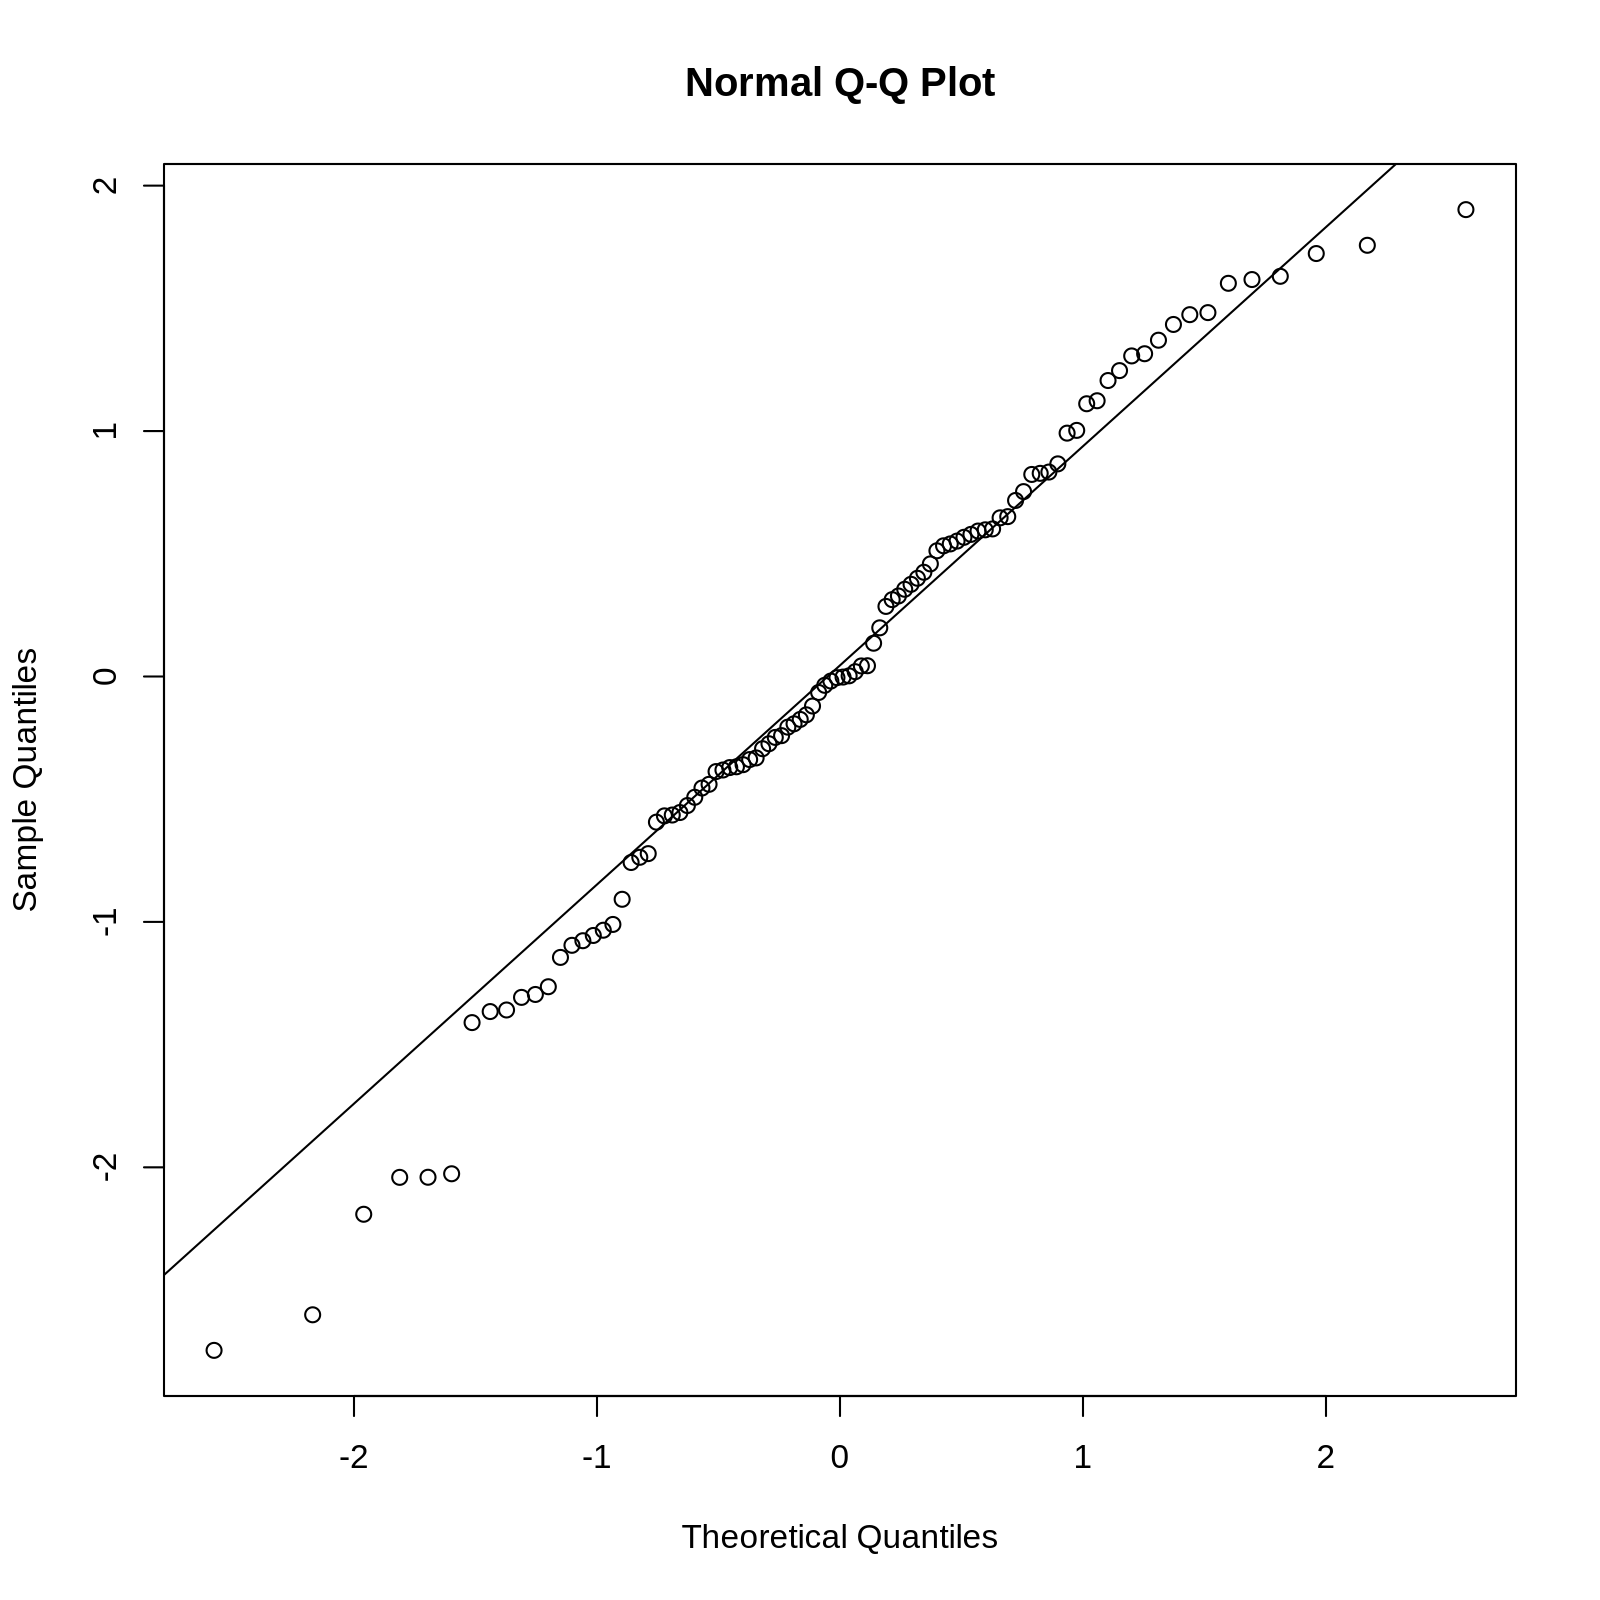

In [ ]:
hist(rstandard(model3), breaks = 20, main = "Standardized Residuals")
qqnorm(rstandard(model3))
qqline(rstandard(model3))
